# Cambio de Medida y Teorema de Radon–Nikodym
**Estadística Bayesiana** | UAEMex Valle de México  
Ximena Quintanar Leal · 2025

> *"La selección es un cambio de medida; la mutación es un núcleo de Markov."*  
> — César Galindo, §1.2

---


## 1. Construcción de una medida vía densidad

Sea $(\Omega, \mathcal{F}, P)$ un espacio de probabilidad. Dada una función $Z \geq 0$ con $E_P[Z] = 1$, definimos una nueva medida:

$$Q(A) = \int_A Z(x)\,P(dx), \quad A \in \mathcal{F}$$

**Interpretación:** $Z$ redistribuye la masa de $P$ — zonas donde $Z > 1$ reciben más peso, zonas con $Z < 1$ reciben menos.

El **Teorema de Radon–Nikodym** garantiza que toda medida $Q \ll P$ (absolutamente continua respecto a $P$) admite exactamente esta representación:

$$\frac{dQ}{dP} = Z \quad \Longleftrightarrow \quad Q(A) = \int_A Z\,dP \text{ para todo } A$$


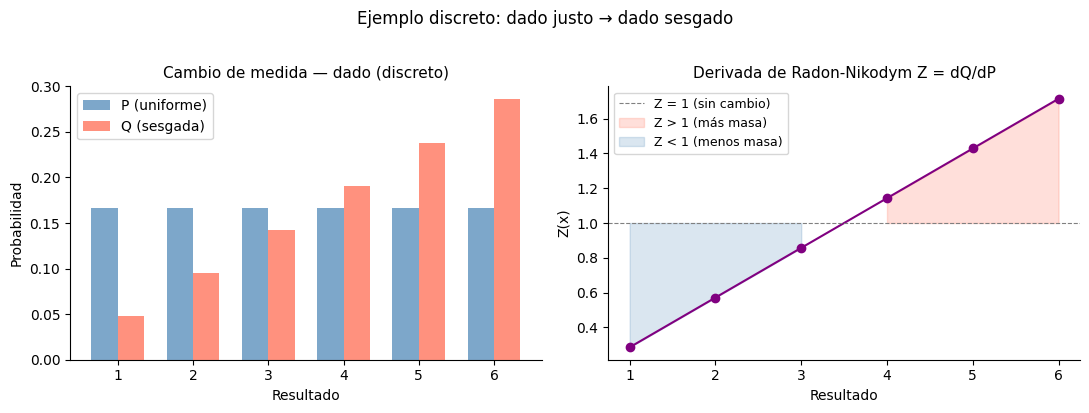

Suma de Q: 1.000000  (debe ser 1)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon

x = np.linspace(0, 1, 500)

# ─── Ejemplo 1 (discreto): dados sesgados ───
omega = np.arange(1, 7)           # dado justo
P_unif = np.ones(6) / 6           # P uniforme
Z_dado = omega / 3.5              # densidad de Radon-Nikodym
Q_dado = Z_dado * P_unif          # nueva medida: sesgada hacia valores altos

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel izquierdo: discreto
width = 0.35
axes[0].bar(omega - width/2, P_unif, width, label='P (uniforme)', color='steelblue', alpha=0.7)
axes[0].bar(omega + width/2, Q_dado, width, label='Q (sesgada)', color='tomato', alpha=0.7)
axes[0].set_xticks(omega)
axes[0].set_title('Cambio de medida — dado (discreto)', fontsize=11)
axes[0].set_xlabel('Resultado'); axes[0].set_ylabel('Probabilidad')
axes[0].legend()
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Panel derecho: densidad Z
axes[1].plot(omega, Z_dado, 'o-', color='purple', linewidth=1.5)
axes[1].axhline(1, color='gray', linestyle='--', linewidth=0.8, label='Z = 1 (sin cambio)')
axes[1].fill_between(omega, 1, Z_dado, where=Z_dado>1, alpha=0.2, color='tomato', label='Z > 1 (más masa)')
axes[1].fill_between(omega, 1, Z_dado, where=Z_dado<1, alpha=0.2, color='steelblue', label='Z < 1 (menos masa)')
axes[1].set_title('Derivada de Radon-Nikodym Z = dQ/dP', fontsize=11)
axes[1].set_xlabel('Resultado'); axes[1].set_ylabel('Z(x)')
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle('Ejemplo discreto: dado justo → dado sesgado', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

print(f"Suma de Q: {Q_dado.sum():.6f}  (debe ser 1)")


## 2. Ejemplo continuo: P = Uniforme[0,1], Z(x) = 2x

$$Z(x) = 2x \implies Q([a,b]) = \int_a^b 2x\,dx = b^2 - a^2$$

$Q$ concentra más masa cerca de $x = 1$.


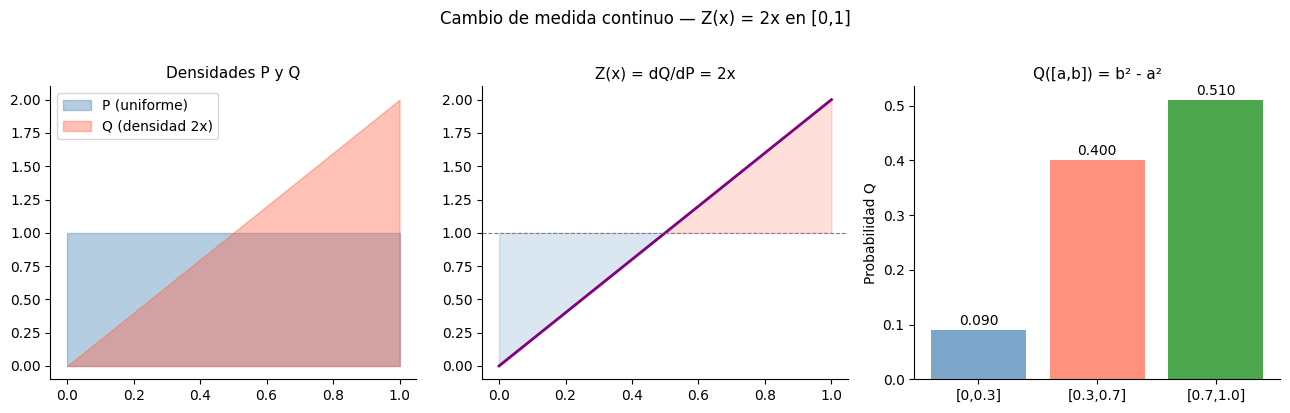

In [2]:
x = np.linspace(0, 1, 500)
Z_cont = 2 * x     # densidad RN: Z(x) = 2x
# P = Lebesgue (densidad constante = 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Densidades
axes[0].fill_between(x, 1, alpha=0.4, color='steelblue', label='P (uniforme)')
axes[0].fill_between(x, Z_cont, alpha=0.4, color='tomato', label='Q (densidad 2x)')
axes[0].set_title('Densidades P y Q', fontsize=11); axes[0].legend()
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Derivada Z
axes[1].plot(x, Z_cont, color='purple', lw=2)
axes[1].axhline(1, color='gray', linestyle='--', lw=0.8)
axes[1].fill_between(x, 1, Z_cont, where=Z_cont>1, alpha=0.2, color='tomato')
axes[1].fill_between(x, 1, Z_cont, where=Z_cont<1, alpha=0.2, color='steelblue')
axes[1].set_title('Z(x) = dQ/dP = 2x', fontsize=11)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

# Verificación: Q([a,b]) = b²-a²
intervalos = [(0,0.3),(0.3,0.7),(0.7,1.0)]
colores_int = ['steelblue','tomato','green']
for (a,b), c in zip(intervalos, colores_int):
    Q_ab_analitica = b**2 - a**2
    axes[2].bar(f'[{a},{b}]', Q_ab_analitica, color=c, alpha=0.7)
    axes[2].text(f'[{a},{b}]', Q_ab_analitica+0.01, f'{Q_ab_analitica:.3f}', ha='center')
axes[2].set_title('Q([a,b]) = b² - a²', fontsize=11)
axes[2].set_ylabel('Probabilidad Q')
axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

plt.suptitle('Cambio de medida continuo — Z(x) = 2x en [0,1]', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


## 3. Identidad fundamental del cambio de medida

$$E_Q[X] = E_P[X \cdot Z]$$

**Consecuencia directa de Radon–Nikodym.** La nueva esperanza bajo $Q$ es simplemente la esperanza bajo $P$ del producto $X \cdot Z$.


In [3]:
rng = np.random.default_rng(42)

# Muestreamos bajo P = Uniforme[0,1]
n_muestras = 200_000
x_p = rng.uniform(0, 1, n_muestras)

# E_Q[X²] por dos métodos:
# Método 1: muestrear bajo P y usar E_Q[X²] = E_P[X² * Z]  (IS)
Z_muestras = 2 * x_p
eq_x2_via_P = np.mean(x_p**2 * Z_muestras)

# Método 2: valor exacto analítico ∫₀¹ x² · 2x dx = 2/4 = 0.5
eq_x2_exacto = 0.5

# Método 3: muestrear bajo Q directamente (inversa: U ~ Unif → X = sqrt(U))
x_q = np.sqrt(rng.uniform(0, 1, n_muestras))
eq_x2_directo = np.mean(x_q**2)

print("Verificación de E_Q[X²] = E_P[X² · Z]:")
print(f"  Analítico:                 {eq_x2_exacto:.6f}")
print(f"  Muestreo bajo P (IS):      {eq_x2_via_P:.6f}")
print(f"  Muestreo directo bajo Q:   {eq_x2_directo:.6f}")
print()

# Demostrar con múltiples funciones
funciones = {'X':   lambda x: x,
             'X²':  lambda x: x**2,
             'sin(πX)': lambda x: np.sin(np.pi*x),
             '√X':  lambda x: np.sqrt(x)}

print(f"{'Función':<12} {'E_P[f·Z]':>12} {'E_Q[f] directo':>15} {'Analítico':>12}")
print('-'*54)
for nombre, f in funciones.items():
    via_P  = np.mean(f(x_p) * Z_muestras)
    directo = np.mean(f(x_q))
    # Analítico: ∫ f(x) 2x dx de 0 a 1
    from scipy.integrate import quad
    analitico, _ = quad(lambda x: f(x)*2*x, 0, 1)
    print(f"{nombre:<12} {via_P:>12.6f} {directo:>15.6f} {analitico:>12.6f}")


Verificación de E_Q[X²] = E_P[X² · Z]:
  Analítico:                 0.500000
  Muestreo bajo P (IS):      0.500008
  Muestreo directo bajo Q:   0.499663

Función          E_P[f·Z]  E_Q[f] directo    Analítico
------------------------------------------------------
X                0.666614        0.666478     0.666667
X²               0.500008        0.499663     0.500000
sin(πX)          0.636417        0.637207     0.636620
√X               0.799936        0.799937     0.800000


## 4. Cambio de medida entre dos gaussianas

Si $P = \mathcal{N}(0,1)$ y $Q = \mathcal{N}(\mu, 1)$, la derivada de Radon–Nikodym es:

$$\frac{dQ}{dP}(x) = e^{\mu x - \mu^2/2}$$

Este es el **exponencial martingala** central en análisis estocástico.


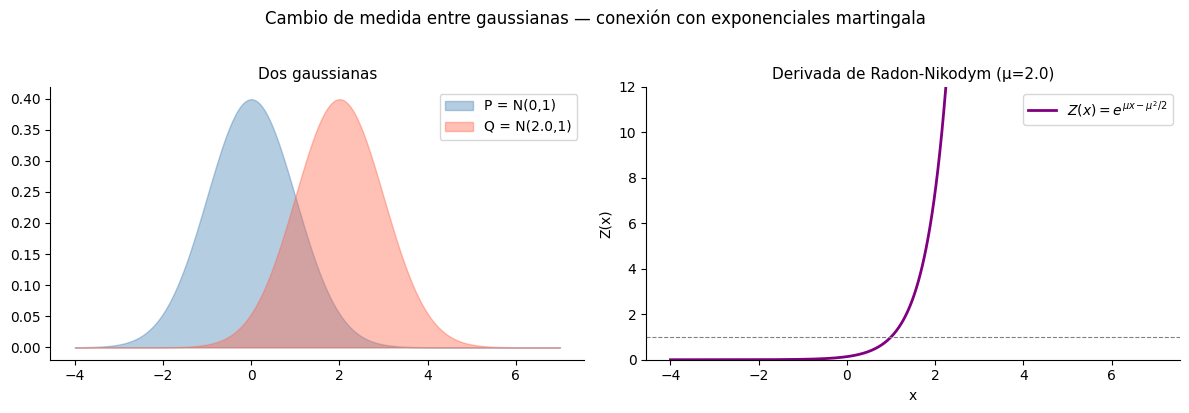

E_P[Z] = 1.004616  (debe ser ≈ 1)


In [4]:
mu = 2.0  # desplazamiento

x_grid = np.linspace(-4, 7, 500)
p_dens = norm.pdf(x_grid, 0, 1)
q_dens = norm.pdf(x_grid, mu, 1)
Z_gauss = np.exp(mu * x_grid - mu**2/2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].fill_between(x_grid, p_dens, alpha=0.4, color='steelblue', label='P = N(0,1)')
axes[0].fill_between(x_grid, q_dens, alpha=0.4, color='tomato', label=f'Q = N({mu},1)')
axes[0].set_title('Dos gaussianas', fontsize=11); axes[0].legend()
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].plot(x_grid, Z_gauss, color='purple', lw=2, label=r'$Z(x) = e^{\mu x - \mu^2/2}$')
axes[1].axhline(1, color='gray', linestyle='--', lw=0.8)
axes[1].set_title(f'Derivada de Radon-Nikodym (μ={mu})', fontsize=11)
axes[1].set_xlabel('x'); axes[1].set_ylabel('Z(x)')
axes[1].legend(); axes[1].set_ylim(0, 12)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle('Cambio de medida entre gaussianas — conexión con exponenciales martingala', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

# Verificación: E_P[Z] debe ser 1
x_p_gauss = rng.normal(0, 1, 100_000)
print(f"E_P[Z] = {np.mean(np.exp(mu*x_p_gauss - mu**2/2)):.6f}  (debe ser ≈ 1)")


## 5. Selección como cambio de medida (conexión con algoritmos genéticos)

Galindo (§1.2) formaliza la **selección genética** como:

$$\Psi_G(\eta)(d\theta) = \frac{G(\theta)}{\eta(G)}\,\eta(d\theta), \qquad \frac{d\Psi_G(\eta)}{d\eta} = \frac{G(\theta)}{\eta(G)}$$

Esto es exactamente Radon–Nikodym: la nueva ley es absolutamente continua respecto a $\eta$, con densidad $G / \eta(G)$.


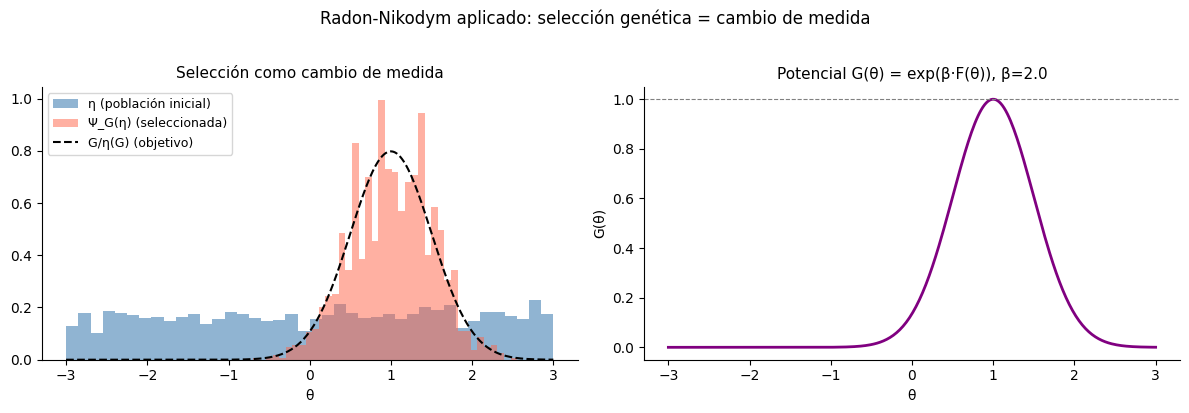

In [5]:
# Simular selección por fitness (cambio de medida en espacio de parámetros)
rng2 = np.random.default_rng(99)

# Población inicial: uniforme en [-3, 3]
N_poblacion = 2000
theta_pop = rng2.uniform(-3, 3, N_poblacion)

# Fitness: G(θ) = exp(F(θ)), con F(θ) = -(θ-1)²  → favorece θ ≈ 1
F = lambda t: -(t - 1)**2
beta = 2.0
G = np.exp(beta * F(theta_pop))

# Pesos de selección (cambio de medida)
pesos = G / G.sum()

# Resamplear según pesos
idx = rng2.choice(N_poblacion, size=N_poblacion, p=pesos)
theta_sel = theta_pop[idx]

theta_grid = np.linspace(-3, 3, 300)
G_norm = np.exp(beta * F(theta_grid))
G_norm /= G_norm.sum() * (theta_grid[1]-theta_grid[0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(theta_pop, bins=40, density=True, color='steelblue', alpha=0.6, label='η (población inicial)')
axes[0].hist(theta_sel, bins=40, density=True, color='tomato',    alpha=0.5, label='Ψ_G(η) (seleccionada)')
axes[0].plot(theta_grid, G_norm, 'k--', lw=1.5, label='G/η(G) (objetivo)')
axes[0].set_title('Selección como cambio de medida', fontsize=11)
axes[0].set_xlabel('θ'); axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].plot(theta_grid, np.exp(beta * F(theta_grid)), color='purple', lw=2)
axes[1].axhline(1, color='gray', linestyle='--', lw=0.8)
axes[1].set_title(f'Potencial G(θ) = exp(β·F(θ)), β={beta}', fontsize=11)
axes[1].set_xlabel('θ'); axes[1].set_ylabel('G(θ)')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle('Radon-Nikodym aplicado: selección genética = cambio de medida', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


---
## Resumen de conexiones

| Contexto | Medida base $P$ | Densidad $Z = dQ/dP$ | Nueva medida $Q$ |
|---|---|---|---|
| Estadística bayesiana | Prior $p(\theta)$ | Verosimilitud $L(y\mid\theta)$ | Posterior $p(\theta\mid y)$ |
| HMM (filtrado) | Predictiva $\phi_{t\mid t-1}$ | Emisión $g(y_t\mid\cdot)$ | Filtrada $\phi_t$ |
| Algoritmos genéticos | Población $\eta_n$ | Fitness $G(\theta)/\eta_n(G)$ | Población seleccionada |
| MCMC | Propuesta $q(x,\cdot)$ | Razón de Hastings $\alpha$ | Invariante $\pi$ |

---
## Referencias
- Galindo, C. *Cambio de medida en probabilidad y análisis estocástico*, §1–§7.
- Gelman, A. et al. (2013). *Bayesian Data Analysis*, 3rd ed.
